# Feature Engineering in Machine Learning

This notebook covers essential feature engineering techniques:
- Handling Missing Values
- Feature Scaling (Normalization & Standardization)
- Encoding Categorical Variables
- Feature Creation & Transformation
- Handling Outliers
- Feature Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Load Dataset

We'll use the Titanic dataset which has missing values, categorical features, and numerical features - perfect for demonstrating feature engineering techniques.

In [2]:
df = pd.read_csv('datasets/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# Create a copy for demonstration
df_clean = df.copy()

# Drop columns with too many missing values (e.g., Cabin)
df_clean = df_clean.drop(columns=['Cabin'])

# Check remaining missing values
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [6]:
# Impute Age with median (numerical, may have outliers)
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Impute Embarked with mode (categorical)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

df_clean.isnull().sum()

C:\Users\Radhakrishna\AppData\Local\Temp\ipykernel_21248\716765806.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
C:\Users\Radhakrishna\AppData\Local\Temp\ipykernel_21248\716765806.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### SimpleImputer (Scikit-learn)

The **SimpleImputer** class provides a clean way to handle missing values that integrates well with sklearn pipelines.

In [7]:
# Using SimpleImputer
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Example usage
age_imputed = num_imputer.fit_transform(df[['Age']])
print(f"Imputed values shape: {age_imputed.shape}")
print(f"Missing values after: {np.isnan(age_imputed).sum()}")

Imputed values shape: (891, 1)
Missing values after: 0


### KNN Imputer

**KNNImputer** uses the k-nearest neighbors approach to impute missing values based on similar samples. More sophisticated but computationally expensive.

In [8]:
# KNN Imputer example
knn_imputer = KNNImputer(n_neighbors=5)

# Select only numerical columns for KNN imputation
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_knn = knn_imputer.fit_transform(df[num_cols])

print(f"Shape: {df_knn.shape}")
print(f"Missing values: {np.isnan(df_knn).sum()}")

Shape: (891, 4)
Missing values: 0


---
## 2. Feature Scaling

Many ML algorithms (KNN, SVM, Neural Networks, Gradient Descent-based) are sensitive to feature scales. Scaling ensures all features contribute equally.

### StandardScaler (Z-score Normalization)
- Transforms data to have **mean = 0** and **std = 1**
- Formula: z = (x - mean) / std
- Use when: Features are normally distributed

### MinMaxScaler (Normalization)
- Scales data to a fixed range, typically **[0, 1]**
- Formula: x_scaled = (x - min) / (max - min)
- Use when: You need bounded values, neural networks

### RobustScaler
- Uses **median** and **IQR** instead of mean/std
- More robust to **outliers**
- Use when: Data has significant outliers

In [9]:
# Sample data for scaling demonstration
sample_data = df_clean[['Age', 'Fare']].copy()
sample_data.describe()

,Age,Fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [10]:
# StandardScaler
standard_scaler = StandardScaler()
scaled_standard = standard_scaler.fit_transform(sample_data)

print("StandardScaler:")
print(f"Mean: {scaled_standard.mean(axis=0)}")
print(f"Std:  {scaled_standard.std(axis=0)}")

StandardScaler:
Mean: [2.27277979e-16 3.98733297e-18]
Std:  [1. 1.]


In [11]:
# MinMaxScaler
minmax_scaler = MinMaxScaler()
scaled_minmax = minmax_scaler.fit_transform(sample_data)

print("MinMaxScaler:")
print(f"Min: {scaled_minmax.min(axis=0)}")
print(f"Max: {scaled_minmax.max(axis=0)}")

MinMaxScaler:
Min: [0. 0.]
Max: [1. 1.]


In [12]:
# RobustScaler
robust_scaler = RobustScaler()
scaled_robust = robust_scaler.fit_transform(sample_data)

print("RobustScaler:")
print(f"Median (should be ~0): {np.median(scaled_robust, axis=0)}")

RobustScaler:
Median (should be ~0): [0. 0.]


---
## 3. Encoding Categorical Variables

Machine learning models require numerical input. We need to convert categorical variables to numbers.

### Label Encoding
- Assigns a unique integer to each category
- Use for: **Ordinal** variables (Low < Medium < High)
- **Warning**: Creates artificial ordering for nominal variables

### One-Hot Encoding
- Creates binary columns for each category
- Use for: **Nominal** variables (no inherent order)
- **Warning**: Can create many columns (high cardinality)

### Ordinal Encoding
- Maps categories to integers with specified order
- Use for: **Ordinal** variables with known order

In [13]:
# Check categorical columns
print("Sex unique values:", df_clean['Sex'].unique())
print("Embarked unique values:", df_clean['Embarked'].unique())
print("Pclass unique values:", df_clean['Pclass'].unique())

Sex unique values: ['male' 'female']
Embarked unique values: ['S' 'C' 'Q']
Pclass unique values: [3 1 2]


### Label Encoding

In [15]:
# Label Encoding for binary variable
le = LabelEncoder()
df_clean['Sex_encoded'] = le.fit_transform(df_clean['Sex'])

print("Label Encoding mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

df_clean[['Sex', 'Sex_encoded']].head()

Label Encoding mapping:
  female -> 0
  male -> 1


,Sex,Sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


### One-Hot Encoding

In [16]:
# One-Hot Encoding using pandas get_dummies
embarked_dummies = pd.get_dummies(df_clean['Embarked'], prefix='Embarked')
embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [17]:
# One-Hot Encoding using sklearn
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid multicollinearity
embarked_encoded = ohe.fit_transform(df_clean[['Embarked']])

print("Feature names:", ohe.get_feature_names_out(['Embarked']))
print("Shape:", embarked_encoded.shape)

Feature names: ['Embarked_Q' 'Embarked_S']
Shape: (891, 2)


### Ordinal Encoding

In [18]:
# Ordinal Encoding with specified order
# Pclass: 1 = First class (best), 2 = Second, 3 = Third (worst)
ordinal_encoder = OrdinalEncoder(categories=[[1, 2, 3]])
df_clean['Pclass_ordinal'] = ordinal_encoder.fit_transform(df_clean[['Pclass']])

df_clean[['Pclass', 'Pclass_ordinal']].head()

,Pclass,Pclass_ordinal
0,3,2.0
1,1,0.0
2,3,2.0
3,1,0.0
4,3,2.0


---
## 4. Feature Creation & Transformation

Creating new features from existing ones can significantly improve model performance.

### Common Techniques:
- **Binning**: Convert continuous to categorical
- **Polynomial Features**: Create interaction terms
- **Log/Square Root Transform**: Handle skewed distributions
- **Domain-specific Features**: Combine features using domain knowledge

In [19]:
# Create new features from existing ones

# Family Size = SibSp + Parch + 1 (self)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# Is Alone
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

df_clean[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


### Binning (Discretization)

Converting continuous variables into discrete bins can help capture non-linear relationships and reduce noise.

In [20]:
# Age binning
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

df_clean['AgeGroup'].value_counts()

AgeGroup
Young Adult    535
Adult          195
Teen            70
Child           69
Senior          22
Name: count, dtype: int64

In [21]:
# Quantile-based binning (equal-frequency bins)
df_clean['FareQuantile'] = pd.qcut(df_clean['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

df_clean['FareQuantile'].value_counts()

FareQuantile
Medium       224
Low          223
High         222
Very High    222
Name: count, dtype: int64

### Log Transformation

Log transformation helps with **right-skewed** distributions, making them more normal-like.

In [22]:
# Check skewness of Fare
print(f"Fare skewness: {df_clean['Fare'].skew():.2f}")

# Log transform (add 1 to handle zeros)
df_clean['Fare_log'] = np.log1p(df_clean['Fare'])

print(f"Fare_log skewness: {df_clean['Fare_log'].skew():.2f}")

Fare skewness: 4.79
Fare_log skewness: 0.39


### Extracting Features from Text

In [24]:
# Extract title from Name
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df_clean['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [25]:
# Simplify rare titles
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Mlle': 'Miss',
    'Countess': 'Rare',
    'Ms': 'Miss',
    'Lady': 'Rare',
    'Jonkheer': 'Rare',
    'Don': 'Rare',
    'Dona': 'Rare',
    'Mme': 'Mrs',
    'Capt': 'Rare',
    'Sir': 'Rare'
}

df_clean['Title'] = df_clean['Title'].map(title_mapping)
df_clean['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

---
## 5. Handling Outliers

Outliers can significantly impact model performance, especially for linear models.

### Detection Methods:
- **IQR Method**: Values outside Q1 - 1.5×IQR or Q3 + 1.5×IQR
- **Z-Score**: Values with |z-score| > 3
- **Visualization**: Box plots, scatter plots

### Treatment Options:
- **Remove**: Drop outlier rows (loses data)
- **Cap/Clip**: Replace with threshold values
- **Transform**: Log/sqrt to reduce impact
- **Impute**: Treat as missing and impute

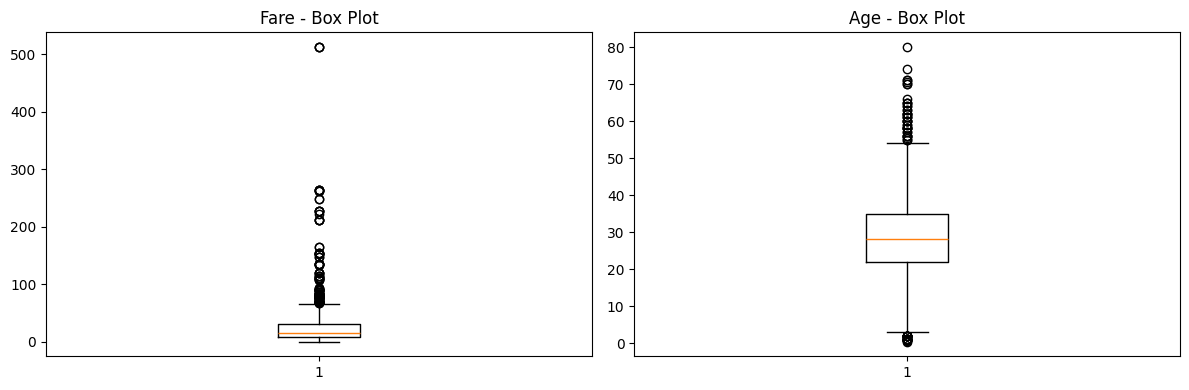

In [26]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_clean['Fare'])
axes[0].set_title('Fare - Box Plot')

axes[1].boxplot(df_clean['Age'])
axes[1].set_title('Age - Box Plot')

plt.tight_layout()
plt.show()

In [27]:
# IQR method for detecting outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

outliers, lower, upper = detect_outliers_iqr(df_clean, 'Fare')
print(f"Fare outliers: {len(outliers)} rows")
print(f"Bounds: [{lower:.2f}, {upper:.2f}]")

Fare outliers: 116 rows
Bounds: [-26.72, 65.63]


In [28]:
# Capping outliers
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

df_capped = df_clean.copy()
df_capped = cap_outliers(df_capped, 'Fare')

print(f"Original Fare max: {df_clean['Fare'].max():.2f}")
print(f"Capped Fare max: {df_capped['Fare'].max():.2f}")

Original Fare max: 512.33
Capped Fare max: 65.63


---
## 6. Feature Selection

Selecting the most relevant features helps:
- Reduce overfitting
- Improve model performance
- Reduce training time
- Improve interpretability

### Methods:
- **Filter Methods**: Statistical tests (correlation, chi-square, ANOVA)
- **Wrapper Methods**: RFE (Recursive Feature Elimination)
- **Embedded Methods**: Feature importance from tree models

In [29]:
# Prepare data for feature selection
df_selection = df_clean[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded', 'FamilySize', 'IsAlone']].dropna()

X = df_selection.drop(columns='Survived')
y = df_selection['Survived']

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,FamilySize,IsAlone
0,3,22.0,1,0,7.2500,1,2,0
1,1,38.0,1,0,71.2833,0,2,0
2,3,26.0,0,0,7.9250,0,1,1
3,1,35.0,1,0,53.1000,0,2,0
4,3,35.0,0,0,8.0500,1,1,1


### Correlation Analysis

In [30]:
# Correlation with target
correlations = df_selection.corr()['Survived'].sort_values(ascending=False)
print("Correlation with Survived:")
print(correlations)

Correlation with Survived:
Survived       1.000000
Fare           0.257307
Parch          0.081629
FamilySize     0.016639
SibSp         -0.035322
Age           -0.064910
IsAlone       -0.203367
Pclass        -0.338481
Sex_encoded   -0.543351
Name: Survived, dtype: float64


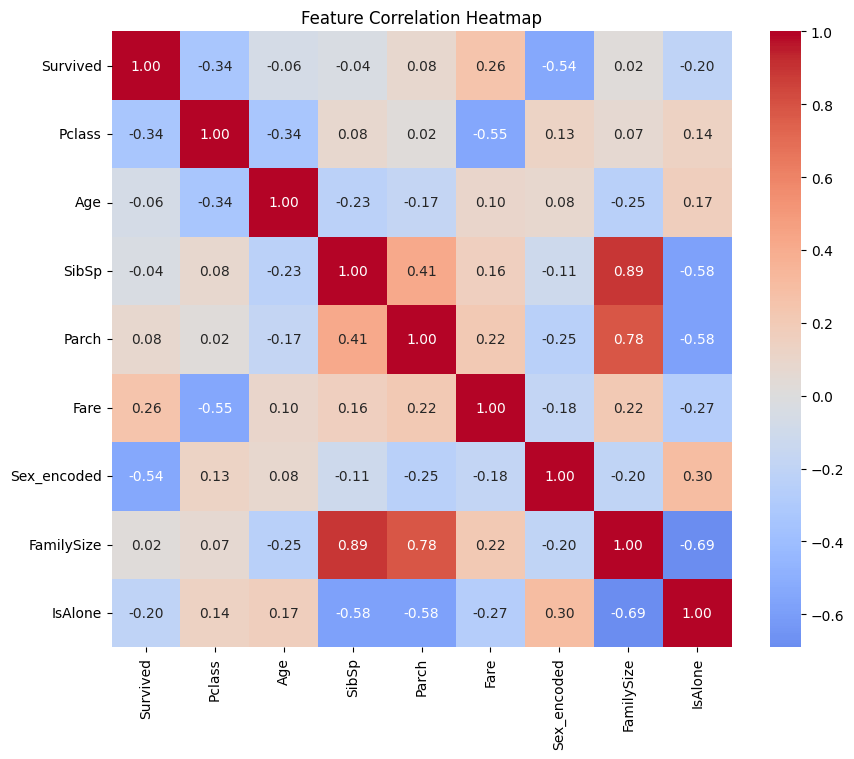

In [31]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_selection.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### SelectKBest (Filter Method)

In [32]:
# SelectKBest with ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print("Top 5 features:")
for feat, score in zip(X.columns, selector.scores_):
    print(f"  {feat}: {score:.2f}")

Top 5 features:
  Pclass: 115.03
  Age: 3.76
  SibSp: 1.11
  Parch: 5.96
  Fare: 63.03
  Sex_encoded: 372.41
  FamilySize: 0.25
  IsAlone: 38.35


### Recursive Feature Elimination (RFE)

In [33]:
from sklearn.linear_model import LogisticRegression

# RFE with Logistic Regression
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X, y)

print("RFE Feature Rankings:")
for feat, rank, selected in zip(X.columns, rfe.ranking_, rfe.support_):
    status = "✓" if selected else " "
    print(f"  {status} {feat}: Rank {rank}")

RFE Feature Rankings:
  ✓ Pclass: Rank 1
    Age: Rank 2
  ✓ SibSp: Rank 1
    Parch: Rank 3
    Fare: Rank 4
  ✓ Sex_encoded: Rank 1
  ✓ FamilySize: Rank 1
  ✓ IsAlone: Rank 1


### Feature Importance from Tree Models

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest to get feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df

,Feature,Importance
4,Fare,0.291983
5,Sex_encoded,0.265789
1,Age,0.260946
0,Pclass,0.081402
6,FamilySize,0.038200
2,SibSp,0.028387
3,Parch,0.021637
7,IsAlone,0.011656


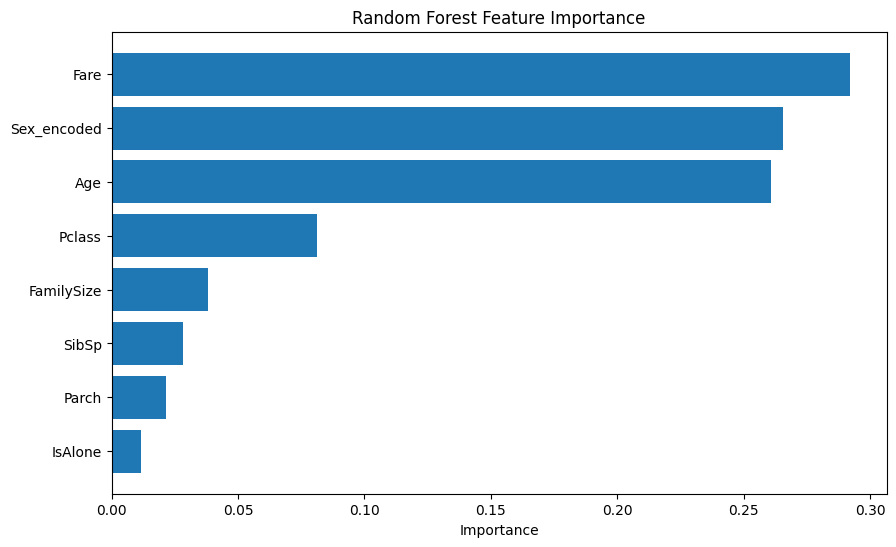

In [35]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

---
## 7. Complete Feature Engineering Pipeline

Using **ColumnTransformer** and **Pipeline** to create a complete preprocessing workflow.

In [36]:
# Define column groups
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass']

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [37]:
# Prepare data
X_full = df[numeric_features + categorical_features]
y_full = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.25, random_state=42)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original shape: {X_train.shape}")
print(f"Processed shape: {X_train_processed.shape}")

Original shape: (668, 7)
Processed shape: (668, 9)


In [38]:
# Full pipeline with model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train
full_pipeline.fit(X_train, y_train)

# Evaluate
train_score = full_pipeline.score(X_train, y_train)
test_score = full_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Train Accuracy: 0.8084
Test Accuracy: 0.7982


---
## 8. Summary: Feature Engineering Checklist

| Step | Technique | When to Use |
|------|-----------|-------------|
| **Missing Values** | Mean/Median/Mode | Numerical/Categorical |
| | KNN Imputer | Complex relationships |
| **Scaling** | StandardScaler | Most ML algorithms |
| | MinMaxScaler | Neural networks, bounded features |
| | RobustScaler | Outliers present |
| **Encoding** | Label Encoding | Ordinal variables |
| | One-Hot Encoding | Nominal variables |
| **Feature Creation** | Binning | Non-linear relationships |
| | Log Transform | Right-skewed data |
| | Domain Features | Use domain knowledge |
| **Outliers** | Cap/Clip | When outliers are noise |
| | Keep | When outliers are meaningful |
| **Feature Selection** | Correlation | Quick analysis |
| | RFE | Wrapper method |
| | Tree Importance | Embedded method |